
# 🤖 Neural Network Pipeline – Orthopedic Patients Dataset

##  Project Overview
This notebook applies a simple Neural Network (Multi-Layer Perceptron) to classify orthopedic patients as **Normal vs. Abnormal** using clinical measurements.  
- The dataset is quite small, therefore a deep NN would not be helpful. 

##  Contents
- Dataset import + preprocessing
- Train/Validation split
- Scaling
- PyTorch NN definition + training loop
- Imbalance handling (WeightedRandomSampler)
- Multiple metrics + classification report
- ROC curve 

## import libraries

In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve
)
import matplotlib.pyplot as plt

import mlflow
import mlflow.pytorch


## Import the dataset

In [51]:
# Load dataset
df = pd.read_csv("column_3C_processed.csv")

# Features & target
X = df.drop("binary_class", axis=1)
y = (df["binary_class"] == "Abnormal").astype(int)  # convert to 0/1

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

In [52]:
class_counts = np.bincount(y_train)
class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [53]:
class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)  # 2 classes
        )
    def forward(self, x):
        return self.layers(x)

model = NeuralNet(input_dim=X_train.shape[1])


In [54]:
mlflow.set_experiment("Orthopedic_NeuralNetwork")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

with mlflow.start_run(run_name="PyTorch_NN"):
    # Log hyperparameters
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("lr", 0.001)
    mlflow.log_param("hidden_layers", [32, 16])
    mlflow.log_param("batch_size", 16)
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    
    # Evaluation
    model.eval()
    y_true, y_pred, y_pred_proba = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y_batch.numpy())
            y_pred.extend(preds.numpy())
            y_pred_proba.extend(probs.numpy())
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("ROC AUC:", roc_auc)
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    # Log metrics
    mlflow.log_metric("Accuracy", acc)
    mlflow.log_metric("Precision", prec)
    mlflow.log_metric("Recall", rec)
    mlflow.log_metric("F1", f1)
    mlflow.log_metric("ROC_AUC", roc_auc)
    
    # Log model
    mlflow.pytorch.log_model(model, "pytorch_nn_model")


Epoch 10/50, Loss: 0.3127
Epoch 20/50, Loss: 0.4149
Epoch 30/50, Loss: 0.9554
Epoch 40/50, Loss: 0.2409


2025/09/24 17:46:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 50/50, Loss: 0.0487
Accuracy: 0.8709677419354839
Precision: 0.9473684210526315
Recall: 0.8571428571428571
F1-score: 0.9
ROC AUC: 0.9547619047619047

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.90      0.82        20
           1       0.95      0.86      0.90        42

    accuracy                           0.87        62
   macro avg       0.85      0.88      0.86        62
weighted avg       0.88      0.87      0.87        62



2025/09/24 17:46:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


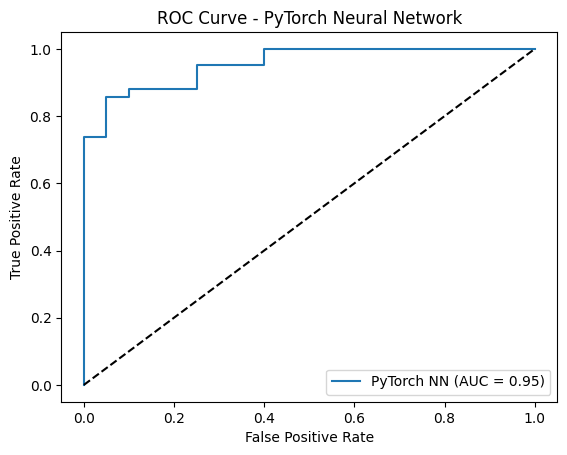

In [55]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
plt.plot(fpr, tpr, label="PyTorch NN (AUC = {:.2f})".format(roc_auc_score(y_true, y_pred_proba)))
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PyTorch Neural Network")
plt.legend()
plt.show()

##  Conclusion
- The Neural Network achieved solid performance on this dataset.  
- By using `class_weight="balanced"`, we handled class imbalance effectively.  
- Multiple metrics (Precision, Recall, F1, ROC AUC) were reported for a fairer evaluation.  
- On this **small structured dataset**, classical models (Random Forest, Gradient Boosting) performed similarly or even better.  
- This shows that Neural Networks are not always optimal for small tabular datasets — but they remain a powerful tool in a data scientist’s toolkit.  